#### An Airbnb Project to help a potential client venture into the space.

##### POTENTIAL QUESTIONS 

1. Profitability of Airbnb over the years and its stability
2. Most active or viable cities and their rates
3. Most booked bedroom types and their rates

###### IMPORTING THE DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\LENOVO\Videos\Maven Analytics\Airbnb Data\Listings.csv",
                encoding = 'ISO-8859-1', low_memory=False,
                parse_dates = ['host_since'])

In [6]:
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


###### BASIC DESCRIPTION AND ANALYSIS OF OUR DATA

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  object        
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[ns]
 4   host_location                278872 non-null  object        
 5   host_response_time           150930 non-null  object        
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  object        
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  object        
 11  host_identity_verified    

###### There are 32 columns and 279712 rows or entries but we will only pick out the columns that we need for our anlysis

In [10]:
air = df[['host_id', 'host_since', 'host_location', 'host_total_listings_count', 'neighbourhood', 'city', 'property_type',
         'room_type', 'accommodates', 'bedrooms', 'amenities', 'price', 'minimum_nights', 'maximum_nights']]
air.head()

,host_id,host_since,host_location,host_total_listings_count,neighbourhood,city,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights
0,1466919,2011-12-03,"Paris, Ile-de-France, France",1.0,Buttes-Montmartre,Paris,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125
1,10328771,2013-11-29,"Paris, Ile-de-France, France",1.0,Buttes-Montmartre,Paris,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125
2,19252768,2014-07-31,"Paris, Ile-de-France, France",1.0,Elysee,Paris,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125
3,10668311,2013-12-17,"Paris, Ile-de-France, France",1.0,Vaugirard,Paris,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125
4,24837558,2014-12-14,"Paris, Ile-de-France, France",1.0,Passy,Paris,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125


In [12]:
air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   host_id                    279712 non-null  int64         
 1   host_since                 279547 non-null  datetime64[ns]
 2   host_location              278872 non-null  object        
 3   host_total_listings_count  279547 non-null  float64       
 4   neighbourhood              279712 non-null  object        
 5   city                       279712 non-null  object        
 6   property_type              279712 non-null  object        
 7   room_type                  279712 non-null  object        
 8   accommodates               279712 non-null  int64         
 9   bedrooms                   250277 non-null  float64       
 10  amenities                  279712 non-null  object        
 11  price                      279712 non-null  int64   

In [14]:
air.describe()

,host_id,host_since,host_total_listings_count,accommodates,bedrooms,price,minimum_nights,maximum_nights
count,2.797120e+05,279547,279547.000000,279712.000000,250277.000000,279712.000000,279712.000000,2.797120e+05
mean,1.081658e+08,2016-04-11 13:01:44.994151680,24.581612,3.288736,1.515509,608.792737,8.050967,2.755860e+04
min,1.822000e+03,2008-08-12 00:00:00,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000e+00
25%,1.720656e+07,2014-07-01 00:00:00,1.000000,2.000000,1.000000,75.000000,1.000000,4.500000e+01
50%,5.826911e+07,2016-02-14 00:00:00,1.000000,2.000000,1.000000,150.000000,2.000000,1.125000e+03
75%,1.832853e+08,2018-04-09 00:00:00,4.000000,4.000000,2.000000,474.000000,5.000000,1.125000e+03
max,3.901874e+08,2021-02-26 00:00:00,7235.000000,16.000000,50.000000,625216.000000,9999.000000,2.147484e+09
std,1.108570e+08,NaN,284.041143,2.133379,1.153080,3441.826611,31.518946,7.282875e+06


###### From our tailored down dataset, we can spot some quick findings
1. We see that the highest persons a listing can accomodate id about 16 persons and the least is just 1 which makes sense
2. The lowest price for a listing is 0 which doesn't make sense except a registered user hasn't made any listing which then makes sense and the highest price is around 625000 as for the currency we are going to assume that it's all in Euros
3. Highest number of bedrooms is 50 and the lowest is 1 

In [16]:
air.select_dtypes(include=['object']).describe()

,host_location,neighbourhood,city,property_type,room_type,amenities
count,278872,279712,279712,279712,279712,279712
unique,7159,660,10,144,4,245003
top,"Paris, Ile-de-France, France",I Centro Storico,Paris,Entire apartment,Entire place,"[""Long term stays allowed""]"
freq,47794,14874,64690,138989,182005,1388


###### We can also see that the city of Paris has the most Airbnb listings and most listings include their entire apartment and not just some rooms

##### CHECKING FOR MISSING VALUES IN OUR DATA

In [18]:
air.isna().sum()

host_id                          0
host_since                     165
host_location                  840
host_total_listings_count      165
neighbourhood                    0
city                             0
property_type                    0
room_type                        0
accommodates                     0
bedrooms                     29435
amenities                        0
price                            0
minimum_nights                   0
maximum_nights                   0
dtype: int64

In [20]:
air.isna().mean()*100

host_id                       0.000000
host_since                    0.058989
host_location                 0.300309
host_total_listings_count     0.058989
neighbourhood                 0.000000
city                          0.000000
property_type                 0.000000
room_type                     0.000000
accommodates                  0.000000
bedrooms                     10.523324
amenities                     0.000000
price                         0.000000
minimum_nights                0.000000
maximum_nights                0.000000
dtype: float64

We have about 10% of values missing from the bedrooms column
We'll have to confirm if it is evenly distributed or just a random distribution to know if it wil affect our analysis

In [23]:
air.loc[air['bedrooms'].isna(), 'city'].value_counts()

city
Paris             13404
New York           3608
Sydney             2209
Bangkok            2142
Istanbul           2034
Rio de Janeiro     1746
Cape Town          1379
Hong Kong          1230
Rome                874
Mexico City         809
Name: count, dtype: int64

We see that most Paris listings do not include the number of bedrooms so this might create a bias in our analysis as Paris has the highest listings so we are going to drop this column and make use of the room type column instead

In [28]:
air.columns

Index(['host_id', 'host_since', 'host_location', 'host_total_listings_count',
       'neighbourhood', 'city', 'property_type', 'room_type', 'accommodates',
       'bedrooms', 'amenities', 'price', 'minimum_nights', 'maximum_nights'],
      dtype='object')

In [30]:
air = air.drop(['host_location', 'bedrooms'], axis=1)
air.columns

Index(['host_id', 'host_since', 'host_total_listings_count', 'neighbourhood',
       'city', 'property_type', 'room_type', 'accommodates', 'amenities',
       'price', 'minimum_nights', 'maximum_nights'],
      dtype='object')

##### ANSWERING SOME OF THE QUESTIONS AND VISUALIZING THEM

###### PROFITABILITY OF AIRBNB OVER THE YEARS

To do this we are going to have to select the data that gives this infomation and make the daate column the index to create a time series plot

In [34]:
profit = (
    air
    .set_index('host_since')
    .resample('YE')
    .agg({'price': 'sum'})
)

profit

,price
host_since,
2008-12-31,5878
2009-12-31,358346
2010-12-31,928525
2011-12-31,3357049
2012-12-31,7338813
2013-12-31,12171355
2014-12-31,20822433
2015-12-31,26091667
2016-12-31,30211182


Text(0.5, 0, 'Years')

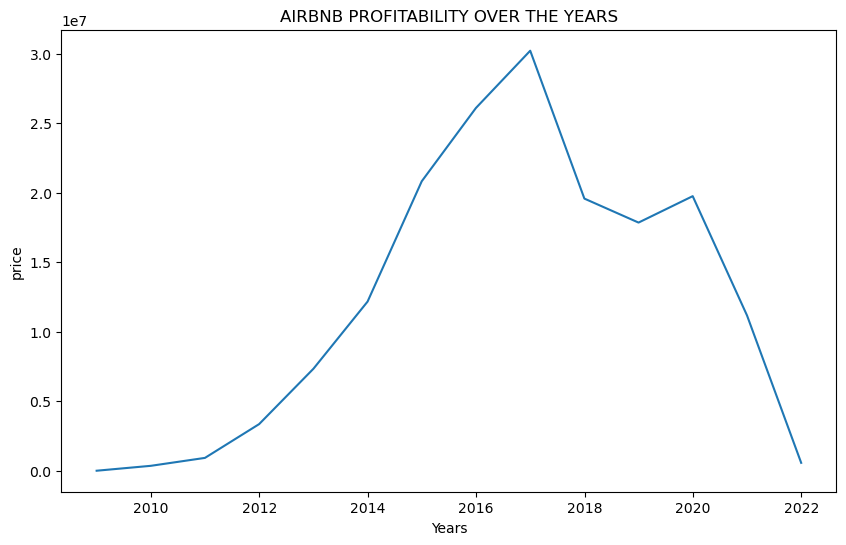

In [48]:
plt.figure(figsize = (10, 6))

sns.lineplot(data = profit, y= 'price', x = 'host_since')

plt.title('AIRBNB PROFITABILITY OVER THE YEARS')

plt.xlabel('Years')

We observe a steady increase in the pricing of listings across the years, with its highest points between 2016 and 2018 and then a sharp drop off from 2019 due to the COVID 19 break out and our dataset is just to 2021, so we can infer that it's highly profitable, but we'll need data after the COVID to justify this.

##### MOST VIABLE CITIES AND THEIR AVERAGE RATINGS FOR DIFFERENT ROOM TYPES

This will require us to do a group by on the cities and then the room types and aggregate on their pricing
We will also create a dataset just showing us the average pricing of each city

In [40]:
city = (
    air
    .groupby('city')
    .agg({'price': 'mean'})
)

city

,price
city,
Bangkok,2078.278033
Cape Town,2405.120350
Hong Kong,746.169889
Istanbul,532.557445
Mexico City,1149.253028
New York,142.842240
Paris,113.096445
Rio de Janeiro,742.589254
Rome,105.107643


In [42]:
cities = (
    air
    .groupby(['city', 'room_type'])
    .agg({'price': 'mean'})
)
cities

price
city           room_type                
Bangkok        Entire place  2155.564059
               Hotel room    2090.751961
               Private room  2037.347204
               Shared room   1323.100690
Cape Town      Entire place  2815.566855
               Hotel room    2929.787582
               Private room  1133.451255
               Shared room    499.291339
Hong Kong      Entire place  1016.570877
               Hotel room     925.577778
               Private room   570.039352
               Shared room    635.551163
Istanbul       Entire place   645.453536
               Hotel room     644.084788
               Private room   405.889675
               Shared room    313.935578
Mexico City    Entire place  1452.071198
               Hotel room    1564.500000
               Private room   795.868954
               Shared room    743.236220
New York       Entire place   191.461308
               Hotel room     228.568562
               Private room    86.318701
               Shared room    100.991254
Paris          Entire place   114.101304
               Hotel room     228.990688
               Private room    87.803123
               Shared room     47.205189
Rio de Janeiro Entire place   823.069277
               Hotel room     325.212121
               Private room   448.315758
               Shared room   1456.738562
Rome           Entire place   114.339170
               Hotel room      96.080721
               Private room    90.041690
               Shared room     38.740000
Sydney         Entire place   293.081491
               Hotel room     201.416309
               Private room   113.728726
               Shared room     63.089226

Text(0.5, 1.0, 'MOST VIABLE CITIES AND ROOM TYPES')

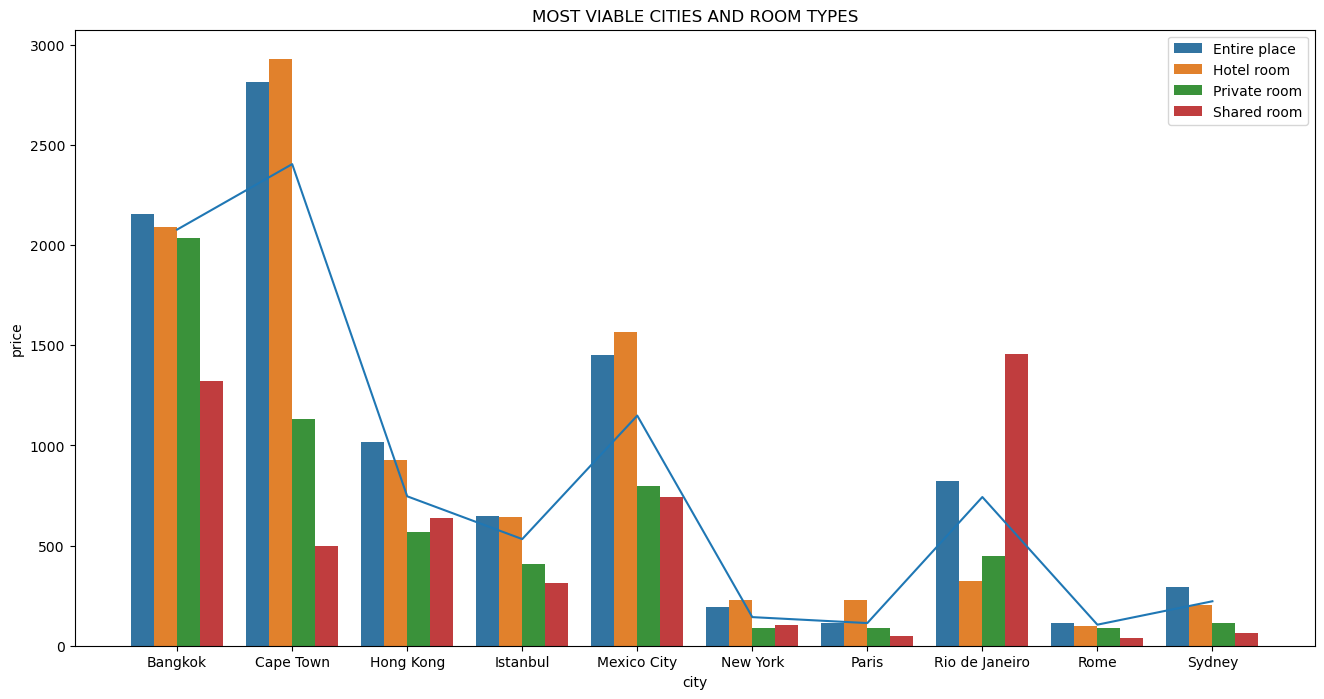

In [44]:
plt.figure(figsize=(16, 8))

sns.barplot(data = cities, x = 'city', y = 'price', hue = 'room_type')
sns.lineplot(data = city, x = 'city', y = 'price')

plt.title('MOST VIABLE CITIES AND ROOM TYPES')

Listings in Cape Town and Bangkok has the highest pricing whilst cities such as Rome, Paris and New York have low pricing, we'll need to confirm if this is as a result of the number of listings in these cities or are these cities not just expensive due to other factors.

We also observe that in most cities, the room type with the highest pricing is either a hotel room or an entire apartment or buildeing, except in Rio where a shared apartment has the highest pricing

In [52]:
air.head()

,host_id,host_since,host_total_listings_count,neighbourhood,city,property_type,room_type,accommodates,amenities,price,minimum_nights,maximum_nights
0,1466919,2011-12-03,1.0,Buttes-Montmartre,Paris,Entire apartment,Entire place,2,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125
1,10328771,2013-11-29,1.0,Buttes-Montmartre,Paris,Entire apartment,Entire place,2,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125
2,19252768,2014-07-31,1.0,Elysee,Paris,Entire apartment,Entire place,2,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125
3,10668311,2013-12-17,1.0,Vaugirard,Paris,Entire apartment,Entire place,2,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125
4,24837558,2014-12-14,1.0,Passy,Paris,Entire apartment,Entire place,2,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125


###### TOTAL NUMBER OF LISTINGS IN EACH CITY

We are going to determine the total number of lisitngs in each city and what kind of room or apartment mkae up those numbers

In [59]:
city_listings = (
    air
    .groupby(['city', 'room_type'])
    .agg({'host_id': 'count'})
)
city_listings

host_id
city           room_type            
Bangkok        Entire place    10623
               Hotel room       1020
               Private room     6993
               Shared room       725
Cape Town      Entire place    14150
               Hotel room        306
               Private room     4503
               Shared room       127
Hong Kong      Entire place     2589
               Hotel room        180
               Private room     3888
               Shared room       430
Istanbul       Entire place    12429
               Hotel room        802
               Private room    10605
               Shared room       683
Mexico City    Entire place    10548
               Hotel room        246
               Private room     8890
               Shared room       381
New York       Entire place    19397
               Hotel room        299
               Private room    16630
               Shared room       686
Paris          Entire place    55378
               Hotel room       1396
               Private room     7492
               Shared room       424
Rio de Janeiro Entire place    19285
               Hotel room         99
               Private room     6619
               Shared room       612
Rome           Entire place    17248
               Hotel room       1276
               Private room     8923
               Shared room       200
Sydney         Entire place    20358
               Hotel room        233
               Private room    12445
               Shared room       594

Text(0.5, 0, 'City')

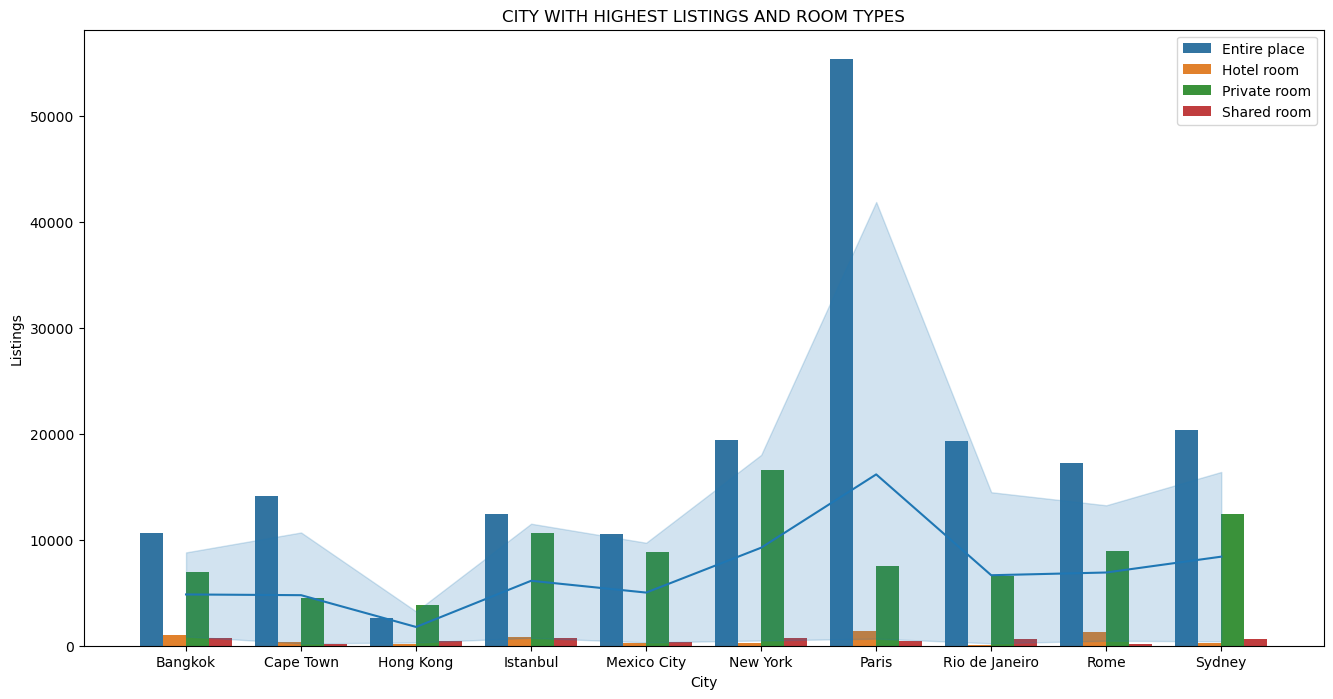

In [83]:
plt.figure(figsize=(16, 8))

sns.barplot(data = city_listings, x = 'city', y = 'host_id', hue = 'room_type')
sns.lineplot(data = city_listings, x = 'city', y = 'host_id')

plt.title('CITY WITH HIGHEST LISTINGS AND ROOM TYPES')

plt.ylabel('Listings')
plt.xlabel('City')

We see that although hotel rooms are more expensive, they are not really high in demand across all 10 cities. But private rooms and entire apartments are more in demand with Paris having the highest listings and still being less expensive.

#### CONCLUSION

From our Analysis we can deduce that Airbnb is actually a profitable business that is actually on a steady rise and we believe it will still be on a steady rise even after the COVID 19 outbreak.

The most expensive listings can be found in Cape Town, Bangkok and Mexico City.

Although Paris isn't that expensive, it has the highest number of listings, with most of its listings being an entire apartment.

So one looking to venture into Airbnb could actually invest in listings in Cape Town, Bangkok or Mexico City, preferably an entire apartment lisitng or a private room listing. 

This doesn't take into consideration the different regulation in these cities